### Train Set과 Test Set의 필요성
- 앞 부분과 같이 문제와 답을 모두 알려주고 해당 범위내에서 점수를 내면 거의 항상 100점이 나온다.
- 하나의 DataSet을 Training부분과 Test부분으로 분리하여 
- Train Set으로 학습을 하고 학습한 내용을 토대로 Test Set으로 검증을 하여야 모델의 정확성을 신뢰할 수 있다.

In [2]:
import pandas as pd
import numpy as np

fruits = pd.read_csv("../Data/fruits.csv")

fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


#### Train Set과 Test Set분리하기

In [4]:
# Train Data 구성하기
train_input = fruits.loc[:34,['length','weight']]
train_input.tail()

,length,weight
30,38.5,920.0
31,38.5,955.0
32,39.5,925.0
33,41.0,975.0
34,41.0,950.0


In [5]:
# train target
train_target = fruits.loc[:34,'name']
train_target.tail()

30    apple
31    apple
32    apple
33    apple
34    apple
Name: name, dtype: object

In [6]:
# 갯수가 일치
len(train_input) == len(train_target)

True

In [8]:
# Test Data 만들기
test_input = fruits.loc[35:,['length','weight']]
test_input.head()

,length,weight
35,9.8,6.7
36,10.5,7.5
37,10.6,7.0
38,11.0,9.7
39,11.2,9.8


In [9]:
# Test Target
test_target = fruits.loc[35:,'name']
test_target.head()

35    berry
36    berry
37    berry
38    berry
39    berry
Name: name, dtype: object

### kNN을 이용한 분류

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# 모델 만들기
kn = KNeighborsClassifier()

In [13]:
# 학습하기

kn.fit(train_input, train_target)

KNeighborsClassifier()

In [16]:
# 검증하기
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

# 샘플링 편향이 발생했다.

1.0
0.0


> 샘플링 편향이 발생하였다.

### Numpy를 이용하여 샘플링 편향을 제거하기

In [18]:
import numpy as np

np.random.seed(42)
index = np.arange(49)
np.random.shuffle(index)
index

array([13, 45, 47, 44, 17, 27, 26, 25, 31, 19, 12,  4, 34,  8,  3,  6, 40,
       41, 46, 15,  9, 16, 24, 33, 30,  0, 43, 32,  5, 29, 11, 36,  1, 21,
        2, 37, 35, 23, 39, 10, 22, 18, 48, 20,  7, 42, 14, 28, 38])

In [20]:
# Train Data
train_input = fruits.loc[index[:35],['length','weight']]
train_input.head()

,length,weight
13,32.0,340.0
45,12.4,13.4
47,14.3,19.7
44,12.2,12.2
17,33.0,700.0


In [21]:
# Train Target
train_target = fruits.loc[index[:35],'name']
train_target.head()

13    apple
45    berry
47    berry
44    berry
17    apple
Name: name, dtype: object

In [23]:
# Test Data
test_input = fruits.loc[index[35:],['length','weight']]
test_input.head()

,length,weight
37,10.6,7.0
35,9.8,6.7
23,35.0,680.0
39,11.2,9.8
10,31.0,475.0


In [25]:
# Test Target
test_target = fruits.loc[index[35:],'name']
test_target.head()

37    berry
35    berry
23    apple
39    berry
10    apple
Name: name, dtype: object

### Data의 분포를 산포도로 확인하기

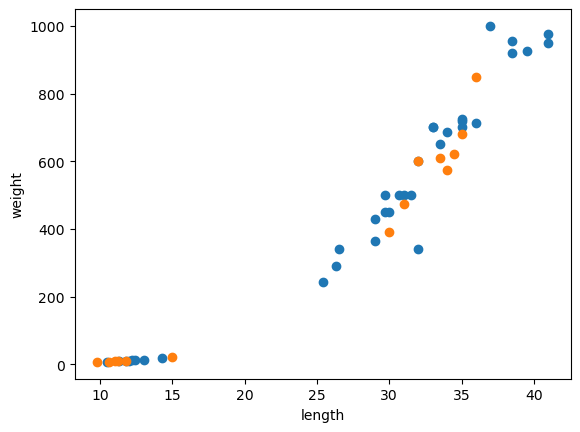

In [26]:
import matplotlib.pyplot as plt

plt.scatter(
  train_input.length,
  train_input.weight
)

plt.scatter(
  test_input.length,
  test_input.weight
)

plt.xlabel('length')
plt.ylabel('weight')

plt.show()

### kNN을 이용한 분류

In [27]:
kn.fit(train_input, train_target)

KNeighborsClassifier()

In [28]:
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))


1.0
1.0


---
### sklearn 으로 Train Set과 Test Set 나누기

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
# Feature 와 Traget분리하기
fruits_data = fruits[['length','weight']]
fruits_target = fruits['name']

In [31]:
train_input, test_input, train_target, test_target = \
  train_test_split(
    fruits_data,
    fruits_target,
    random_state=42
  )

In [32]:
print(train_input.shape)
print(test_input.shape)
print(train_target.shape)
print(test_target.shape)

(36, 2)
(13, 2)
(36,)
(13,)


In [33]:
train_target.value_counts()

name
apple    25
berry    11
Name: count, dtype: int64

In [34]:
test_target.value_counts()

name
apple    10
berry     3
Name: count, dtype: int64

In [35]:
import collections # 빈도수 세기

In [40]:
train_counts = collections.Counter(train_target)
train_counts['apple'] / train_counts['berry']

2.272727272727273

In [39]:
test_counts = collections.Counter(test_target)
test_counts['apple'] / test_counts['berry']

3.3333333333333335

In [41]:
len(fruits[fruits.name == 'apple']) / \
  len(fruits[fruits.name == 'berry'])

2.5

#### 분류(Classification) 시 데이터가 동일한 비율로 섞이게

In [42]:
train_input, test_input, train_target, test_target = \
  train_test_split(
    fruits_data,
    fruits_target,
    random_state=42,
    stratify=fruits_target
  )

In [43]:
train_counts = collections.Counter(train_target)
train_counts['apple'] / train_counts['berry']

2.6

In [44]:
test_counts = collections.Counter(test_target)
test_counts['apple'] / test_counts['berry']

2.25

In [45]:
print(train_input.shape)
print(test_input.shape)
print(train_target.shape)
print(test_target.shape)

(36, 2)
(13, 2)
(36,)
(13,)


In [46]:
train_target.value_counts()

name
apple    26
berry    10
Name: count, dtype: int64

In [47]:
test_target.value_counts()

name
apple    9
berry    4
Name: count, dtype: int64

In [ ]:
kn.fit(train_input, train_target)

KNeighborsClassifier()

In [49]:
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))


1.0
1.0
